# le-wm Turbofan Benchmark

Three downstream evaluation tasks on a **frozen** JEPA encoder loaded from a training checkpoint.

| # | Task | Metric |
|---|------|--------|
| 1 | **HI State Estimation** — predict 10 turbofan health indicators from a single encoder embedding | R², RMSE, Pearson-r per HI dim |
| 2 | **Action-Horizon (RUL) Prediction** — predict steps to next maintenance from embeddings | RMSE, MAE, R² (uncensored) |
| 3 | **Latent Forecasting** — autoregressively roll out the world model for τ steps, decode z_t to HI, measure reconstruction vs. horizon | RMSE(τ), R²(τ) curves |

Tasks 1 & 2 train a lightweight TransformerProbe on top of frozen embeddings.  
Task 3 uses `JEPA.rollout()` directly — no additional training needed.


In [30]:
# ── Config — edit these paths ─────────────────────────────────────────────────
CHECKPOINT_PATH = "/Users/lucas-andreithil/.stable_worldmodel/turbofan_v6_sensor_sl1_w10/lewm_turbo_v6_sensor_sl1_w10_epoch_100_object.ckpt.ckpt"  # torch.save'd JEPA
HDF5_PATH       = "/Users/lucas-andreithil/PycharmProjects/rl_simulator_safran/data/opendeck_2000.h5"   # le-wm HDF5 dataset

ENCODER_TYPE    = "sensor"   # "sensor" or "vit"
TRAIN_SPLIT     = 0.9        # must match training run
SEED            = 3072       # must match training run

# Probe hyper-params (Task 1 & 2)
PROBE_SEQ_LEN   = 1          # 1 = single-snapshot; >1 = trajectory window
N_PROBE_EPOCHS  = 150
PROBE_LR        = 1e-3
PROBE_PATIENCE  = 20
PROBE_BATCH     = 256
D_MODEL         = 64
NHEAD           = 4
NUM_LAYERS      = 2
DROPOUT         = 0.1
N_SUBSAMPLE     = 30_000     # max timesteps to load per split
ENC_BATCH       = 2048       # encoding batch size
RUL_MAX_HORIZON = 300        # cap for Action-RUL probe

# Task 3 — latent forecasting
FORECAST_HORIZONS = list(range(1, 31))   # τ values to evaluate
FORECAST_N_EPS    = 200                  # number of test episodes to use
HISTORY_SIZE      = 3                    # context frames fed to the predictor
IMG_SIZE          = 28                   # only used for ViT encoder


In [34]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # adjust if needed

import copy
import logging
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# le-wm imports
from jepa import JEPA
from hi_probe import _TransformerProbe, HIProbeCallback

logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")
warnings.filterwarnings("ignore", category=UserWarning)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## Load model from checkpoint

In [35]:
# ModelObjectCallBack saves the raw JEPA object with torch.save(model, path),
# so we just torch.load it directly — no Lightning wrapper needed.
model: JEPA = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.eval()
model = model.to(DEVICE)

embed_dim = sum(p.numel() for p in model.parameters())
print(f"JEPA loaded  |  {embed_dim:,} parameters")
print(f"encoder_type : {model.encoder_type}")


FileNotFoundError: [Errno 2] No such file or directory: '/Users/lucas-andreithil/.stable_worldmodel/turbofan_v6_sensor_sl1_w10/lewm_turbo_v6_sensor_sl1_w10_epoch_100_object.ckpt'

## Load dataset from HDF5

In [13]:
def load_hdf5(path, encoder_type, train_split=0.9, seed=3072):
    """Load observations, HI states, actions from le-wm HDF5.

    Returns
    -------
    tr / te dicts each containing:
        obs      : np.ndarray  — (N, n_sensors) for sensor enc; (N, H, W) for ViT
        hi       : np.ndarray  — (N, n_hi_dims)
        actions  : np.ndarray  — (N,) float
        ep_ids   : np.ndarray  — (N,) int episode index per timestep
    Also returns hi_names : list[str]
    """
    with h5py.File(path, "r") as f:
        ep_len    = f["ep_len"][:]
        ep_offset = f["ep_offset"][:]
        obs_key   = "pixels" if "pixels" in f else "observation.sensors"
        pixels    = f[obs_key][:]
        if encoder_type == "sensor" and pixels.ndim > 2:
            pixels = pixels.reshape(len(pixels), -1)  # (N, n_sensors)
        states    = f["observation.state"][:]
        hi_names  = list(f.attrs.get("state_label_names",
                                      [f"HI_{i}" for i in range(states.shape[1])]))
        actions   = f["action"][:]
        if actions.ndim > 1:
            actions = actions[:, 0]
        print(f"Loaded  |  obs={pixels.shape}  states={states.shape}  "
              f"actions={actions.shape}  episodes={len(ep_len)}")

    N_EP = len(ep_len)
    rng  = np.random.default_rng(seed)
    perm = rng.permutation(N_EP)
    n_tr = int(N_EP * train_split)
    tr_eps = perm[:n_tr]
    te_eps = perm[n_tr:]

    def gather(eps):
        all_obs, all_hi, all_act, all_ep = [], [], [], []
        for local_i, e in enumerate(eps):
            s, l = int(ep_offset[e]), int(ep_len[e])
            all_obs.append(pixels[s : s + l])
            all_hi.append(states[s : s + l])
            all_act.append(actions[s : s + l])
            all_ep.append(np.full(l, local_i, dtype=np.int32))
        return dict(
            obs    = np.concatenate(all_obs),
            hi     = np.concatenate(all_hi),
            actions= np.concatenate(all_act),
            ep_ids = np.concatenate(all_ep),
            ep_offset = ep_offset,
            ep_len    = ep_len,
            eps       = eps,
        )

    return gather(tr_eps), gather(te_eps), hi_names


tr_data, te_data, HI_NAMES = load_hdf5(
    HDF5_PATH, ENCODER_TYPE, TRAIN_SPLIT, SEED
)
print(f"Train: {len(tr_data['obs']):,}  Test: {len(te_data['obs']):,}  HI dims: {len(HI_NAMES)}")
print("HI names:", HI_NAMES)


Loaded  |  obs=(1101300, 28)  states=(1101300, 10)  actions=(1101300,)  episodes=559
Train: 989,855  Test: 111,445  HI dims: 10
HI names: ['deg_CmpBst_s_mapEff_in', 'deg_CmpBst_s_mapWc_in', 'deg_CmpFan_s_mapEff_in', 'deg_CmpFan_s_mapWc_in', 'deg_CmpH_s_mapEff_in', 'deg_CmpH_s_mapWc_in', 'deg_TrbH_s_mapEff_in', 'deg_TrbH_s_mapWc_in', 'deg_TrbL_s_mapEff_in', 'deg_TrbL_s_mapWc_in']


## Shared: encode observations → embeddings

In [14]:
@torch.no_grad()
def encode_observations(model, obs, encoder_type, batch_size=ENC_BATCH, img_size=IMG_SIZE):
    """Encode a numpy array of observations to JEPA embeddings.

    Parameters
    ----------
    obs : (N, n_sensors) for sensor encoder  OR  (N, H, W) for ViT

    Returns
    -------
    embeddings : (N, embed_dim) numpy

    Notes
    -----
    When obs_window_size > 1 the encoder's TemporalAggregator needs at least
    w frames to produce one output.  For single-snapshot evaluation we tile
    each frame w times so T_raw = w → T_out = 1.  This is semantically
    equivalent to a snapshot encoder: the TemporalAggregator attends over w
    identical copies of the same frame, so the result represents that frame.
    """
    is_sensor = (encoder_type == "sensor")
    w = getattr(model, 'obs_window_size', 1)   # frames the encoder expects per output
    if not is_sensor:
        mean = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)

    all_emb = []
    for start in range(0, len(obs), batch_size):
        chunk = obs[start : start + batch_size]
        if is_sensor:
            t = torch.from_numpy(chunk).float().to(DEVICE).unsqueeze(1)  # (B, 1, n_sensors)
            if w > 1:
                t = t.expand(-1, w, -1).contiguous()   # (B, w, n_sensors)
        else:
            t = torch.from_numpy(chunk).float().to(DEVICE)
            if t.ndim == 3:
                t = t.unsqueeze(1).expand(-1, 3, -1, -1)   # (B, H, W) → (B, 3, H, W)
            t = F.interpolate(t, size=(img_size, img_size), mode="nearest")
            t = (t - mean) / std
            t = t.unsqueeze(1)   # (B, 1, C, H, W)
            if w > 1:
                t = t.expand(-1, w, -1, -1, -1).contiguous()   # (B, w, C, H, W)
        out = model.encode({"pixels": t})
        # T_out = T_raw - w + 1 = w - w + 1 = 1  →  index 0 is always the one output
        all_emb.append(out["emb"][:, 0, :].cpu().numpy())
    return np.concatenate(all_emb, axis=0)


print("Encoding train observations…")
Z_tr = encode_observations(model, tr_data["obs"], ENCODER_TYPE)
print(f"  Z_tr: {Z_tr.shape}")
print("Encoding test observations…")
Z_te = encode_observations(model, te_data["obs"], ENCODER_TYPE)
print(f"  Z_te: {Z_te.shape}")

Encoding train observations…
  Z_tr: (989855, 64)
Encoding test observations…
  Z_te: (111445, 64)


---
## Task 1 — HI State Estimation
Train a TransformerProbe on frozen embeddings to predict the 10 health indicators.

In [15]:
def train_probe(X_tr, y_tr, X_te, y_te,
                ep_ids_tr, ep_ids_te,
                n_outputs, task_name="HI",
                n_epochs=N_PROBE_EPOCHS, lr=PROBE_LR,
                patience=PROBE_PATIENCE, batch_size=PROBE_BATCH,
                seq_len=PROBE_SEQ_LEN,
                d_model=D_MODEL, nhead=NHEAD,
                num_layers=NUM_LAYERS, dropout=DROPOUT):
    """Train a TransformerProbe and return predictions on the test set."""
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    Xw_tr, yw_tr = HIProbeCallback._build_windows(X_tr_s, y_tr, ep_ids_tr, seq_len)
    Xw_te, yw_te = HIProbeCallback._build_windows(X_te_s, y_te, ep_ids_te, seq_len)
    print(f"  [{task_name}] windows  train={len(Xw_tr):,}  test={len(Xw_te):,}  "
          f"input_dim={Xw_tr.shape[2]}")

    probe = _TransformerProbe(
        input_dim=Xw_tr.shape[2], n_outputs=n_outputs,
        d_model=d_model, nhead=nhead, num_layers=num_layers, dropout=dropout
    ).to(DEVICE)
    opt = torch.optim.Adam(probe.parameters(), lr=lr)

    Xtr_t = torch.from_numpy(Xw_tr).float().to(DEVICE)
    ytr_t = torch.from_numpy(yw_tr).float().to(DEVICE)
    Xte_t = torch.from_numpy(Xw_te).float().to(DEVICE)
    dl    = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xtr_t, ytr_t),
        batch_size=batch_size, shuffle=True
    )

    best_rmse, best_state, patience_ctr = float("inf"), None, 0
    for ep in range(n_epochs):
        probe.train()
        for xb, yb in dl:
            opt.zero_grad(); F.mse_loss(probe(xb), yb).backward(); opt.step()
        probe.eval()
        with torch.no_grad():
            pv = probe(Xte_t).cpu().numpy()
        rmse = float(np.mean(np.sqrt(np.mean((yw_te - pv) ** 2, axis=0))))
        if rmse < best_rmse:
            best_rmse = rmse; best_state = copy.deepcopy(probe.state_dict()); patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            print(f"  [{task_name}] early stop at epoch {ep+1}  best_rmse={best_rmse:.5f}")
            break

    probe.load_state_dict(best_state)
    probe.eval()
    with torch.no_grad():
        preds = probe(Xte_t).cpu().numpy()
    return preds, yw_te


# ── Run Task 1 ────────────────────────────────────────────────────────────────
print("Task 1 — HI State Estimation")
hi_tr = tr_data["hi"]
hi_te = te_data["hi"]

preds_hi, gt_hi = train_probe(
    Z_tr, hi_tr, Z_te, hi_te,
    tr_data["ep_ids"], te_data["ep_ids"],
    n_outputs=hi_tr.shape[1],
    task_name="HI",
)


Task 1 — HI State Estimation
  [HI] windows  train=989,855  test=111,445  input_dim=64
  [HI] early stop at epoch 75  best_rmse=0.00265


In [16]:
# ── Task 1 metrics ────────────────────────────────────────────────────────────
print("\n=== Task 1: HI State Estimation ===")
print(f"{'Component':<30}  {'R²':>6}  {'RMSE':>8}  {'Pearson':>8}")
print("-" * 60)
r2s, rmses, pearson_rs = [], [], []
for i, name in enumerate(HI_NAMES):
    gt, pr = gt_hi[:, i], preds_hi[:, i]
    r2  = float(r2_score(gt, pr))
    rmse = float(np.sqrt(np.mean((gt - pr) ** 2)))
    r, _ = pearsonr(gt, pr)
    r2s.append(r2); rmses.append(rmse); pearson_rs.append(float(r))
    short = name.replace("deg_Cmp", "").replace("_s_mapEff_in", "/Eff").replace("_s_mapWc_in", "/Wc")
    print(f"  {short:<28}  {r2:>6.3f}  {rmse:>8.5f}  {float(r):>8.3f}")
print("-" * 60)
print(f"  {'MEAN':<28}  {np.mean(r2s):>6.3f}  {np.mean(rmses):>8.5f}  {np.mean(pearson_rs):>8.3f}")



=== Task 1: HI State Estimation ===
Component                           R²      RMSE   Pearson
------------------------------------------------------------
  Bst/Eff                        0.687   0.00264     0.840
  Bst/Wc                         0.678   0.00272     0.831
  Fan/Eff                        0.700   0.00255     0.843
  Fan/Wc                         0.807   0.00184     0.901
  H/Eff                          0.833   0.00314     0.913
  H/Wc                           0.746   0.00388     0.864
  deg_TrbH/Eff                   0.763   0.00216     0.875
  deg_TrbH/Wc                    0.635   0.00242     0.799
  deg_TrbL/Eff                   0.733   0.00238     0.862
  deg_TrbL/Wc                    0.644   0.00277     0.809
------------------------------------------------------------
  MEAN                           0.723   0.00265     0.854


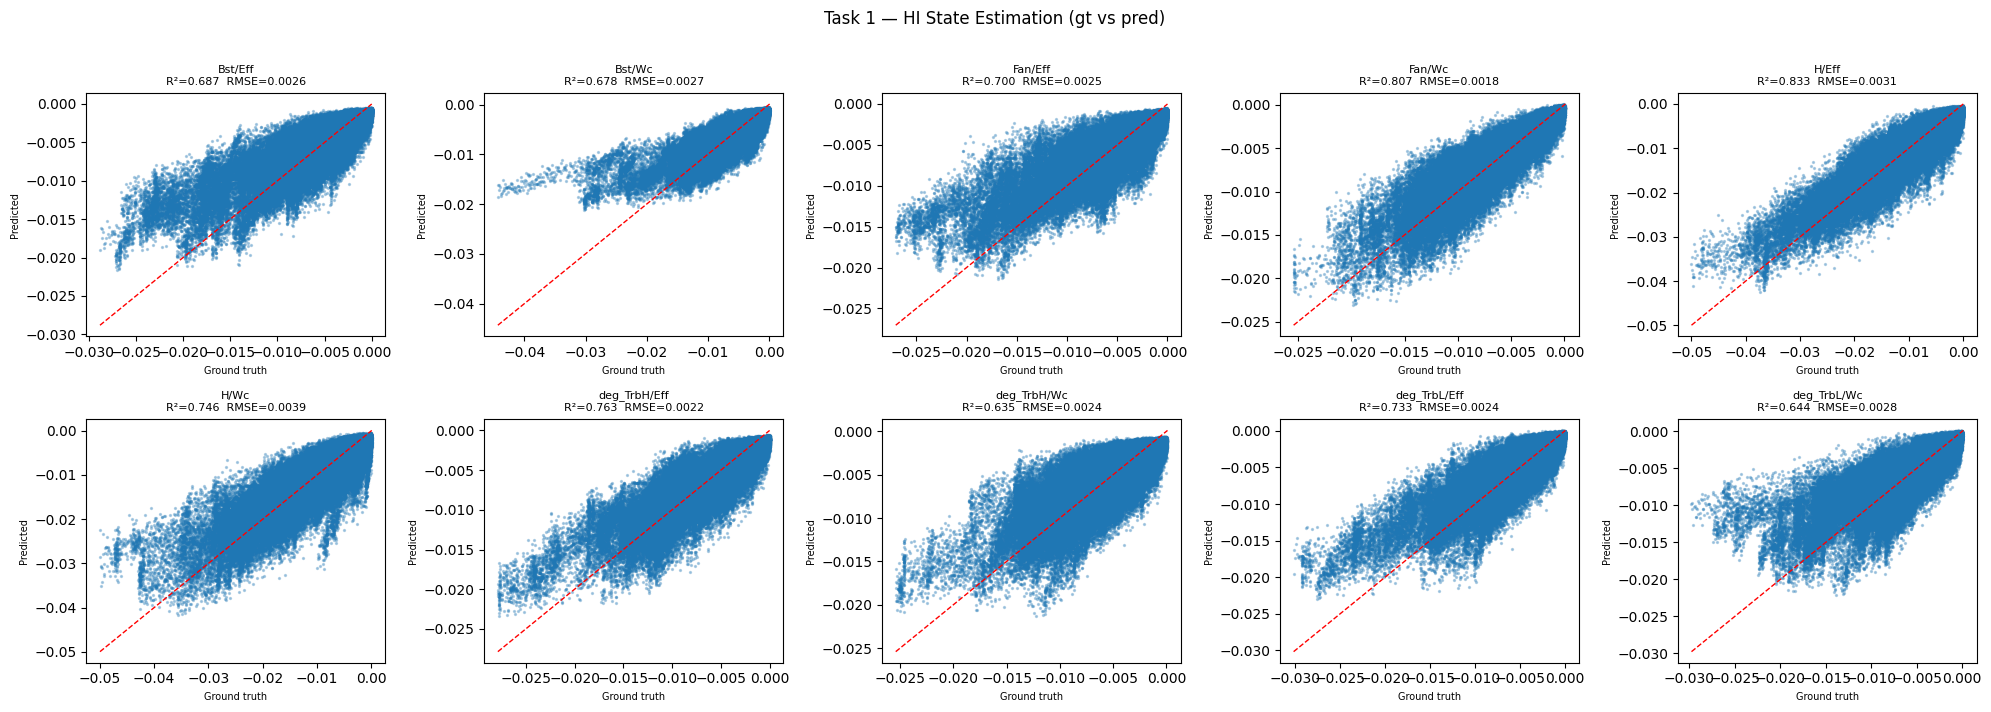

In [17]:
# ── Task 1 visualisation ──────────────────────────────────────────────────────
n_dims = len(HI_NAMES)
ncols  = min(5, n_dims)
nrows  = (n_dims + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = np.array(axes).flatten()
for i, (name, ax) in enumerate(zip(HI_NAMES, axes)):
    ax.scatter(gt_hi[:, i], preds_hi[:, i], s=2, alpha=0.3)
    lo, hi_ = min(gt_hi[:, i].min(), preds_hi[:, i].min()), max(gt_hi[:, i].max(), preds_hi[:, i].max())
    ax.plot([lo, hi_], [lo, hi_], "r--", lw=1)
    short = name.replace("deg_Cmp", "").replace("_s_mapEff_in", "/Eff").replace("_s_mapWc_in", "/Wc")
    ax.set_title(f"{short}\nR²={r2s[i]:.3f}  RMSE={rmses[i]:.4f}", fontsize=8)
    ax.set_xlabel("Ground truth", fontsize=7)
    ax.set_ylabel("Predicted", fontsize=7)
for ax in axes[n_dims:]:
    ax.set_visible(False)
fig.suptitle("Task 1 — HI State Estimation (gt vs pred)", y=1.01)
fig.tight_layout()
plt.savefig("task1_hi_estimation.pdf", bbox_inches="tight")
plt.show()


---
## Task 2 — Action-Horizon (RUL) Prediction
Predict steps to next maintenance action from frozen embeddings.

In [26]:
# Compute RUL targets
with h5py.File(HDF5_PATH, "r") as f:
    all_actions  = f["action"][:]
    all_ep_len   = f["ep_len"][:]
    all_ep_offset= f["ep_offset"][:]
if all_actions.ndim > 1:
    all_actions = all_actions[:, 0]

rul_full = HIProbeCallback._compute_rul(
    all_actions, all_ep_offset, all_ep_len, RUL_MAX_HORIZON
)

# Gather RUL for train / test splits  (reuse the ep indices from load_hdf5)
def gather_rul(eps, ep_offset, ep_len, rul_full):
    all_rul = []
    for e in eps:
        s, l = int(ep_offset[e]), int(ep_len[e])
        all_rul.append(rul_full[s : s + l])
    return np.concatenate(all_rul)

rul_tr = gather_rul(tr_data["eps"], all_ep_offset, all_ep_len, rul_full)
rul_te = gather_rul(te_data["eps"], all_ep_offset, all_ep_len, rul_full)
print(f"RUL  train={rul_tr.shape}  test={rul_te.shape}")
n_maint = int((all_actions > 0.5).sum())
print(f"Maintenance events in full dataset: {n_maint}")


RUL  train=(989855,)  test=(111445,)
Maintenance events in full dataset: 2823


In [27]:
# ── log1p scale + normalise targets ──────────────────────────────────────────
rul_tr_log = np.log1p(rul_tr).reshape(-1, 1).astype(np.float32)
rul_te_log = np.log1p(rul_te).reshape(-1, 1).astype(np.float32)
scaler_rul = StandardScaler()
rul_tr_s = scaler_rul.fit_transform(rul_tr_log)
rul_te_s = scaler_rul.transform(rul_te_log)

preds_rul_s, gt_rul_s = train_probe(
    Z_tr, rul_tr_s, Z_te, rul_te_s,
    tr_data["ep_ids"], te_data["ep_ids"],
    n_outputs=1,
    task_name="RUL",
)


  [RUL] windows  train=989,855  test=111,445  input_dim=64
  [RUL] early stop at epoch 40  best_rmse=0.97381


In [28]:
# ── De-normalise and evaluate on uncensored samples ───────────────────────────
preds_raw = np.expm1(scaler_rul.inverse_transform(preds_rul_s)).clip(min=0).ravel()
gt_raw    = np.expm1(scaler_rul.inverse_transform(gt_rul_s)).clip(min=0).ravel()

uncensored  = gt_raw < RUL_MAX_HORIZON
frac_uncens = float(uncensored.sum()) / max(len(gt_raw), 1)
print(f"Uncensored test samples: {uncensored.sum()} / {len(gt_raw)} ({frac_uncens:.1%})")

gt_eval    = gt_raw[uncensored] if uncensored.sum() >= 20 else gt_raw
preds_eval = preds_raw[uncensored] if uncensored.sum() >= 20 else preds_raw

rul_rmse     = float(np.sqrt(np.mean((gt_eval - preds_eval) ** 2)))
rul_mae      = float(np.mean(np.abs(gt_eval - preds_eval)))
rul_r2       = float(r2_score(gt_eval, preds_eval))
rul_pearson  = float(pearsonr(gt_eval, preds_eval)[0])

print("\n=== Task 2: Action-Horizon (RUL) Prediction ===")
print(f"  RMSE     : {rul_rmse:.2f} steps")
print(f"  MAE      : {rul_mae:.2f} steps")
print(f"  R²       : {rul_r2:.3f}")
print(f"  Pearson-r: {rul_pearson:.3f}")


Uncensored test samples: 111445 / 111445 (100.0%)

=== Task 2: Action-Horizon (RUL) Prediction ===
  RMSE     : 28.44 steps
  MAE      : 24.74 steps
  R²       : -0.055
  Pearson-r: 0.232


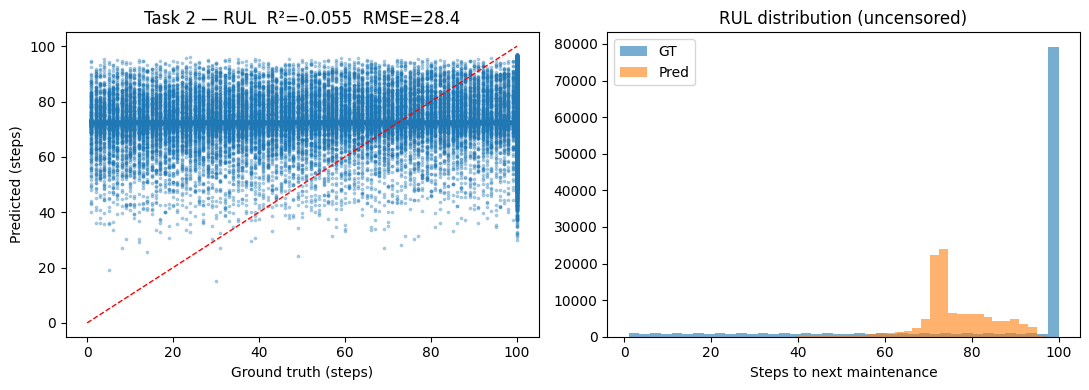

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].scatter(gt_eval, preds_eval, s=3, alpha=0.3)
lim = max(gt_eval.max(), preds_eval.max())
ax[0].plot([0, lim], [0, lim], "r--", lw=1)
ax[0].set_xlabel("Ground truth (steps)"); ax[0].set_ylabel("Predicted (steps)")
ax[0].set_title(f"Task 2 — RUL  R²={rul_r2:.3f}  RMSE={rul_rmse:.1f}")

ax[1].hist(gt_eval, bins=40, alpha=0.6, label="GT")
ax[1].hist(preds_eval, bins=40, alpha=0.6, label="Pred")
ax[1].set_xlabel("Steps to next maintenance")
ax[1].set_title("RUL distribution (uncensored)")
ax[1].legend()

fig.tight_layout()
plt.savefig("task2_rul_prediction.pdf", bbox_inches="tight")
plt.show()


---
## Task 3 — Latent Forecasting

Given an initial context (first `HISTORY_SIZE` observations of a test episode), the world model rolls out `τ` latent predictions autoregressively using `JEPA.predict()`.  We then apply the trained HI probe (from Task 1) to each predicted `z_{t+τ}` and compare the decoded HI reconstruction to the ground truth.

This measures how well the *dynamics model* captures degradation trajectories — above and beyond what the encoder alone can represent.

In [ ]:
# ── Re-train HI probe, keep probe object for decoding ─────────────────────────
print("Re-training HI probe for Task-3 decoder…")

scaler_probe = StandardScaler()
Z_tr_s = scaler_probe.fit_transform(Z_tr)
Z_te_s = scaler_probe.transform(Z_te)

Xw_tr3, yw_tr3 = HIProbeCallback._build_windows(
    Z_tr_s, hi_tr, tr_data["ep_ids"], seq_len=1
)
probe3 = _TransformerProbe(
    input_dim=Xw_tr3.shape[2], n_outputs=hi_tr.shape[1],
    d_model=D_MODEL, nhead=NHEAD, num_layers=NUM_LAYERS, dropout=DROPOUT
).to(DEVICE)

opt3 = torch.optim.Adam(probe3.parameters(), lr=PROBE_LR)
Xtr3_t = torch.from_numpy(Xw_tr3).float().to(DEVICE)
ytr3_t = torch.from_numpy(yw_tr3).float().to(DEVICE)
dl3 = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(Xtr3_t, ytr3_t),
    batch_size=PROBE_BATCH, shuffle=True
)

# Quick training pass — we want the probe weights for decoding predicted z's
best_rmse3, best_state3, patience_ctr3 = float("inf"), None, 0
Xte3_t = torch.from_numpy(
    HIProbeCallback._build_windows(Z_te_s, hi_te, te_data["ep_ids"], 1)[0]
).float().to(DEVICE)
yte3 = HIProbeCallback._build_windows(Z_te_s, hi_te, te_data["ep_ids"], 1)[1]

for ep in range(N_PROBE_EPOCHS):
    probe3.train()
    for xb, yb in dl3:
        opt3.zero_grad(); F.mse_loss(probe3(xb), yb).backward(); opt3.step()
    probe3.eval()
    with torch.no_grad():
        pv = probe3(Xte3_t).cpu().numpy()
    rmse3 = float(np.mean(np.sqrt(np.mean((yte3 - pv)**2, axis=0))))
    if rmse3 < best_rmse3:
        best_rmse3 = rmse3; best_state3 = copy.deepcopy(probe3.state_dict()); patience_ctr3 = 0
    else:
        patience_ctr3 += 1
    if patience_ctr3 >= PROBE_PATIENCE:
        print(f"  [Probe3] early stop ep {ep+1}  rmse={best_rmse3:.5f}"); break

probe3.load_state_dict(best_state3)
probe3.eval()
print(f"HI probe (for Task 3 decoder) ready  (val mean RMSE = {best_rmse3:.5f})")


In [ ]:
@torch.no_grad()
def decode_z_to_hi(probe, scaler, z_np):
    """Apply StandardScaler normalisation and the HI probe to z_np.

    z_np : (N, D) numpy  — raw JEPA embeddings (unnormalized)
    Returns (N, n_hi) numpy predictions.
    """
    z_s = scaler.transform(z_np)                        # (N, D)
    z_t = torch.from_numpy(z_s[:, np.newaxis, :]).float().to(DEVICE)  # (N, 1, D)
    return probe(z_t).cpu().numpy()                     # (N, n_hi)


@torch.no_grad()
def latent_forecast_episode(
    model, obs_ep, hi_ep, probe, scaler,
    encoder_type, max_tau, history_size=HISTORY_SIZE,
    img_size=IMG_SIZE,
):
    """Run one episode through the JEPA world model and evaluate HI reconstruction
    at every forecast horizon τ = 1 … max_tau.

    Procedure
    ---------
    For each valid starting frame t in the episode:
      1. Encode context window  obs_ep[t - H + 1 : t + 1]  →  z_context  (H, D)
      2. Autoregressively predict  z_{t+1}, …, z_{t+τ}  with JEPA.predict()
      3. Decode each z_{t+τ} to ĥi using the HI probe.
      4. Compare ĥi to gt hi_ep[t+τ].

    Returns
    -------
    rmse_per_tau : (max_tau, n_hi_dims)  — per-dimension RMSE at each horizon
    count_per_tau: (max_tau,)            — number of valid (t, τ) pairs
    """
    T, n_hi = len(obs_ep), hi_ep.shape[1]
    is_sensor = (encoder_type == "sensor")

    # Pre-encode all frames in the episode
    z_ep = encode_observations(model, obs_ep, encoder_type, batch_size=512, img_size=img_size)
    # z_ep : (T, D)

    sqerr_sum = np.zeros((max_tau, n_hi), dtype=np.float64)
    count     = np.zeros(max_tau, dtype=np.int64)

    H = history_size
    for t in range(H - 1, T - 1):
        # Context: last H embeddings ending at t
        ctx = torch.from_numpy(z_ep[t - H + 1 : t + 1]).float().to(DEVICE)  # (H, D)
        ctx = ctx.unsqueeze(0)  # (1, H, D)

        # No action: use zero action embedding (or actual actions if available)
        act_emb = torch.zeros(1, H, ctx.shape[-1], device=DEVICE)  # (1, H, D)

        # Roll out τ steps autoregressively
        emb_window = ctx.clone()   # (1, H, D)
        for tau in range(1, max_tau + 1):
            target_t = t + tau
            if target_t >= T:
                break

            # Predict next embedding from last H embeddings
            pred_z = model.predict(emb_window[:, -H:], act_emb[:, -H:])  # (1, H, D)
            next_z = pred_z[:, -1:]  # (1, 1, D) — last predicted step

            # Decode predicted embedding to HI
            hi_pred = decode_z_to_hi(probe, scaler, next_z[:, 0].cpu().numpy())  # (1, n_hi)
            hi_gt   = hi_ep[target_t:target_t+1]  # (1, n_hi)

            sqerr_sum[tau - 1] += ((hi_pred - hi_gt) ** 2)[0]
            count[tau - 1]     += 1

            # Append predicted z to rolling window
            emb_window = torch.cat([emb_window, next_z], dim=1)  # (1, H+tau, D)
            # Extend act_emb to match new length
            act_emb = torch.cat([
                act_emb,
                torch.zeros(1, 1, ctx.shape[-1], device=DEVICE)
            ], dim=1)

    return sqerr_sum, count


print("Task 3 — Latent Forecasting")
print(f"Evaluating {FORECAST_N_EPS} test episodes  ×  τ ∈ [1, {max(FORECAST_HORIZONS)}]…")

max_tau  = max(FORECAST_HORIZONS)
n_hi     = hi_te.shape[1]
sqerr_sum_all = np.zeros((max_tau, n_hi))
count_all     = np.zeros(max_tau, dtype=np.int64)

# Gather per-episode obs / HI from test set
with h5py.File(HDF5_PATH, "r") as f:
    ep_len_all    = f["ep_len"][:]
    ep_offset_all = f["ep_offset"][:]
    obs_key = "pixels" if "pixels" in f else "observation.sensors"
    all_obs_raw = f[obs_key][:]
    if ENCODER_TYPE == "sensor" and all_obs_raw.ndim > 2:
        all_obs_raw = all_obs_raw.reshape(len(all_obs_raw), -1)
    all_states = f["observation.state"][:]

te_eps = te_data["eps"]
n_eval = min(FORECAST_N_EPS, len(te_eps))

for i, ep_idx in enumerate(te_eps[:n_eval]):
    if i % 20 == 0:
        print(f"  episode {i}/{n_eval}…")
    s = int(ep_offset_all[ep_idx])
    l = int(ep_len_all[ep_idx])
    obs_ep = all_obs_raw[s : s + l]
    hi_ep  = all_states[s : s + l]

    if l < HISTORY_SIZE + 1:
        continue  # episode too short

    se, cnt = latent_forecast_episode(
        model, obs_ep, hi_ep, probe3, scaler_probe,
        ENCODER_TYPE, max_tau,
    )
    sqerr_sum_all += se
    count_all     += cnt

# ── RMSE(τ) and R²(τ) curves ─────────────────────────────────────────────────
rmse_tau  = np.sqrt(sqerr_sum_all / np.maximum(count_all[:, None], 1))  # (max_tau, n_hi)
mean_rmse_tau = rmse_tau.mean(axis=1)  # (max_tau,)
print("Done.")


In [ ]:
# ── Task 3 results ────────────────────────────────────────────────────────────
print("=== Task 3: Latent Forecasting — Mean HI RMSE vs. horizon τ ===")
print(f"{'τ':>4}  {'RMSE (mean)':>12}  {'count':>8}")
print("-" * 30)
for tau in FORECAST_HORIZONS:
    print(f"  {tau:>2}  {mean_rmse_tau[tau-1]:>12.5f}  {count_all[tau-1]:>8,}")


In [ ]:
# ── Task 3 visualisation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: per-dim RMSE curves
ax = axes[0]
taus = np.array(FORECAST_HORIZONS)
for i, name in enumerate(HI_NAMES):
    short = name.replace("deg_Cmp", "").replace("_s_mapEff_in", "/Eff").replace("_s_mapWc_in", "/Wc")
    ax.plot(taus, rmse_tau[taus - 1, i], alpha=0.7, label=short)
ax.plot(taus, mean_rmse_tau[taus - 1], "k--", lw=2.5, label="Mean")
ax.set_xlabel("Forecast horizon τ (steps)")
ax.set_ylabel("HI RMSE")
ax.set_title("Task 3 — HI RMSE vs. Latent Forecast Horizon")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

# Right: compare τ=1 probe (Task 1) with τ=1 forecasting
ax2 = axes[1]
enc_rmse = np.array(rmses)   # Task 1 per-dim RMSE (encoder only)
fc1_rmse = rmse_tau[0]       # Task 3 τ=1 per-dim RMSE (1-step forecast)
x = np.arange(len(HI_NAMES))
width = 0.35
ax2.bar(x - width/2, enc_rmse, width, label="Task 1 (encoder, τ=0)", alpha=0.8)
ax2.bar(x + width/2, fc1_rmse, width, label="Task 3 (1-step forecast)", alpha=0.8)
short_names = [
    n.replace("deg_Cmp", "").replace("_s_mapEff_in", "/Eff").replace("_s_mapWc_in", "/Wc")
    for n in HI_NAMES
]
ax2.set_xticks(x); ax2.set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("RMSE")
ax2.set_title("Encoder (τ=0) vs 1-step forecast")
ax2.legend(); ax2.grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.savefig("task3_latent_forecasting.pdf", bbox_inches="tight")
plt.show()


---
## Summary table

In [ ]:
print("="*65)
print(" le-wm Turbofan Benchmark — Summary")
print("="*65)
print(f" Checkpoint  : {CHECKPOINT_PATH}")
print(f" Encoder     : {ENCODER_TYPE}")
print(f" Probe seq   : {PROBE_SEQ_LEN}")
print()
print(" Task 1 — HI State Estimation")
print(f"   Mean R²       : {np.mean(r2s):.3f}")
print(f"   Mean RMSE      : {np.mean(rmses):.5f}")
print(f"   Mean Pearson-r : {np.mean(pearson_rs):.3f}")
print()
print(" Task 2 — Action-Horizon (RUL) Prediction")
print(f"   RMSE           : {rul_rmse:.2f} steps")
print(f"   MAE            : {rul_mae:.2f} steps")
print(f"   R²             : {rul_r2:.3f}")
print(f"   Pearson-r      : {rul_pearson:.3f}")
print(f"   Frac uncensored: {frac_uncens:.1%}")
print()
print(" Task 3 — Latent Forecasting (mean HI RMSE)")
for tau in [1, 5, 10, 20, max(FORECAST_HORIZONS)]:
    if tau <= max(FORECAST_HORIZONS):
        print(f"   τ={tau:>2}           : {mean_rmse_tau[tau-1]:.5f}")
print("="*65)
